# Figure 1 — Morphological diversity across development

This notebook builds a reproducible morphology database from the **35 GM3-validated OPC reconstructions**, performs exploratory and inferential analyses across P10, P20 and P50, selects representative cells objectively, and generates a draft manuscript figure.

### Main outputs

- `figure1_outputs/morphology_master_table.csv`
- `figure1_outputs/sholl_source_data.csv`
- `figure1_outputs/statistical_summary.csv`
- `figure1_outputs/pairwise_statistics.csv`
- `figure1_outputs/representative_cells.csv`
- `figure1_outputs/Figure1_morphological_diversity.png`
- `figure1_outputs/Figure1_morphological_diversity.pdf`

The original legacy `.xls` workbooks are not parsed here: GM3 already contains their converted Neurolucida tables, ensuring that the measurements correspond exactly to the validated reconstructions used by GM4–GM7.

In [1]:
from pathlib import Path
import json
import math
import shutil
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -------------------------------------------------------------------------
# USER CONFIGURATION
# -------------------------------------------------------------------------
# Put this notebook beside cells.zip and BasicAnalyses.zip, or edit the paths.
BASE_DIR = Path.cwd()
GM3_ZIP = BASE_DIR / "cells.zip"
BASIC_ZIP = BASE_DIR / "BasicAnalyses.zip"  # inventory/cross-check only
WORK_DIR = BASE_DIR / "figure1_work"
OUTPUT_DIR = BASE_DIR / "figure1_outputs"

AGE_ORDER = ["P10", "P20", "P50"]
AGE_COLORS = {"P10": "#4477AA", "P20": "#EE6677", "P50": "#228833"}

WORK_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("GM3 archive:", GM3_ZIP)
print("BasicAnalyses archive:", BASIC_ZIP)
print("Output directory:", OUTPUT_DIR)

GM3 archive: /mnt/data/fig1_run/cells.zip
BasicAnalyses archive: /mnt/data/fig1_run/BasicAnalyses.zip
Output directory: /mnt/data/fig1_run/figure1_outputs


## 1. Extract and locate the validated data

In [2]:
def extract_once(zip_path: Path, destination: Path) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f"Missing archive: {zip_path}")
    marker = destination / ".extracted"
    if marker.exists():
        return
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(destination)
    marker.touch()

GM3_EXTRACT = WORK_DIR / "gm3"
BASIC_EXTRACT = WORK_DIR / "basic"
extract_once(GM3_ZIP, GM3_EXTRACT)
if BASIC_ZIP.exists():
    extract_once(BASIC_ZIP, BASIC_EXTRACT)

# Locate the directory whose children are cell folders containing manifest.json.
candidate_roots = []
for p in GM3_EXTRACT.rglob("cells"):
    if p.is_dir() and any((child / "manifest.json").exists() for child in p.iterdir() if child.is_dir()):
        candidate_roots.append(p)
if not candidate_roots:
    raise RuntimeError("Could not locate the GM3 cells directory")
CELLS_ROOT = candidate_roots[0]
cell_dirs = sorted([p for p in CELLS_ROOT.iterdir() if p.is_dir() and (p / "manifest.json").exists()])

print("Validated cell root:", CELLS_ROOT)
print("Number of validated cell folders:", len(cell_dirs))
assert len(cell_dirs) == 35, f"Expected 35 validated cells, found {len(cell_dirs)}"

Validated cell root: /mnt/data/fig1_run/figure1_work/gm3/cells
Number of validated cell folders: 35


## 2. Build the 35-cell morphology database

In [3]:
def read_one_csv(cell_dir: Path, suffix: str, required: bool=True) -> pd.DataFrame | None:
    matches = list(cell_dir.rglob(f"*{suffix}"))
    if len(matches) == 0 and not required:
        return None
    if len(matches) != 1:
        raise RuntimeError(f"Expected one {suffix} in {cell_dir.name}, found {len(matches)}")
    return pd.read_csv(matches[0])


def read_reconstruction(cell_dir: Path) -> dict:
    matches = list(cell_dir.rglob("*_reconstruction.json"))
    matches = [p for p in matches if not p.name.endswith("_diagnostics.json")]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one reconstruction JSON in {cell_dir.name}, found {len(matches)}")
    return json.loads(matches[0].read_text())


def numeric(series):
    return pd.to_numeric(series, errors="coerce")


def sholl_auc(radius, intersections):
    order = np.argsort(radius)
    return float(np.trapezoid(intersections[order], radius[order]))

rows = []
sholl_frames = []
reconstructions = {}

for cell_dir in cell_dirs:
    cell_id = cell_dir.name
    age = cell_id.rsplit("_", 1)[-1]
    if age not in AGE_ORDER:
        raise ValueError(f"Unexpected age group in {cell_id}")

    neuron = read_one_csv(cell_dir, "_basic_Neuron_Summary.csv")
    nodes = read_one_csv(cell_dir, "_basic_Node_Dendrite.csv")
    terminals = read_one_csv(cell_dir, "_basic_Terminal_Dendrite.csv")
    sholl = read_one_csv(cell_dir, "_sholl_Sholl_Dendrite.csv", required=False)
    recon = read_reconstruction(cell_dir)
    reconstructions[cell_id] = recon

    dend = neuron.loc[neuron["name"].astype(str).str.strip().eq("Dendrite")]
    soma = neuron.loc[neuron["name"].astype(str).str.strip().eq("Cell body")]
    if len(dend) != 1:
        raise RuntimeError(f"Missing/ambiguous Dendrite summary for {cell_id}")
    dend = dend.iloc[0]

    segs = pd.DataFrame(recon["segments"])
    for col in ["length_um", "order", "straight_length_um"]:
        segs[col] = numeric(segs[col])

    node_dist = numeric(nodes["distance_along_proce"]) if "distance_along_proce" in nodes else pd.Series(dtype=float)
    node_tort = numeric(nodes["tortuosity"]) if "tortuosity" in nodes else pd.Series(dtype=float)

    if sholl is not None:
        sholl["radius_um"] = numeric(sholl["radius_um"])
        sholl["intersections"] = numeric(sholl["intersections"])
        sholl["length_um"] = numeric(sholl["length_um"])
        sholl = sholl.dropna(subset=["radius_um", "intersections"])
        sholl["cell_id"] = cell_id
        sholl["age"] = age
        sholl_frames.append(sholl[["cell_id", "age", "radius_um", "intersections", "length_um"]])
        nonzero_sholl = sholl.loc[sholl["intersections"] > 0]
        max_sholl_radius = float(nonzero_sholl["radius_um"].max()) if not nonzero_sholl.empty else np.nan
        peak_idx = sholl["intersections"].idxmax()
        peak_sholl = float(sholl.loc[peak_idx, "intersections"])
        radius_peak = float(sholl.loc[peak_idx, "radius_um"])
        sholl_auc_value = sholl_auc(sholl["radius_um"].to_numpy(), sholl["intersections"].to_numpy())
    else:
        max_sholl_radius = np.nan
        peak_sholl = np.nan
        radius_peak = np.nan
        sholl_auc_value = np.nan

    n_terminals = int((segs["terminal_type"].astype(str).str.lower() != "node").sum()) if "terminal_type" in segs else int(dend.get("ends", np.nan))
    n_branch_segments = int(segs["child_ids"].apply(lambda x: len(x) if isinstance(x, list) else 0).gt(0).sum()) if "child_ids" in segs else int(dend.get("nodes", np.nan))

    rows.append({
        "cell_id": cell_id,
        "age": age,
        "total_process_length_um": float(dend["length_um"]),
        "n_primary_trees": int(dend["qty"]),
        "n_nodes_neurolucida": int(dend["nodes"]),
        "n_endings_neurolucida": int(dend["ends"]),
        "complexity_neurolucida": float(dend["complexity"]),
        "soma_area_um2": float(recon.get("soma_area_um2", np.nan)),
        "n_reconstructed_segments": int(len(segs)),
        "n_branch_segments": n_branch_segments,
        "n_terminal_segments": n_terminals,
        "mean_segment_length_um": float(segs["length_um"].mean()),
        "median_segment_length_um": float(segs["length_um"].median()),
        "max_segment_order": float(segs["order"].max()),
        "mean_segment_order": float(segs["order"].mean()),
        "mean_node_path_distance_um": float(node_dist.mean()),
        "max_node_path_distance_um": float(node_dist.max()),
        "mean_node_tortuosity": float(node_tort.mean()),
        "max_radial_extent_um": max_sholl_radius,
        "peak_sholl_intersections": peak_sholl,
        "radius_at_peak_sholl_um": radius_peak,
        "sholl_auc_intersections_um": sholl_auc_value,
    })

morph = pd.DataFrame(rows)
morph["age"] = pd.Categorical(morph["age"], categories=AGE_ORDER, ordered=True)
morph = morph.sort_values(["age", "cell_id"]).reset_index(drop=True)
sholl_all = pd.concat(sholl_frames, ignore_index=True)
sholl_all["age"] = pd.Categorical(sholl_all["age"], categories=AGE_ORDER, ordered=True)

morph.to_csv(OUTPUT_DIR / "morphology_master_table.csv", index=False)
sholl_all.to_csv(OUTPUT_DIR / "sholl_source_data.csv", index=False)

print(morph.groupby("age", observed=True).size())
print("\nMaster table shape:", morph.shape)
display(morph.head())

age
P10    12
P20    12
P50    11
dtype: int64

Master table shape: (35, 22)


,cell_id,age,total_process_length_um,n_primary_trees,n_nodes_neurolucida,n_endings_neurolucida,complexity_neurolucida,soma_area_um2,n_reconstructed_segments,n_branch_segments,n_terminal_segments,mean_segment_length_um,median_segment_length_um,max_segment_order,mean_segment_order,mean_node_path_distance_um,max_node_path_distance_um,mean_node_tortuosity,max_radial_extent_um,peak_sholl_intersections,radius_at_peak_sholl_um,sholl_auc_intersections_um
0,NX22_1_P10,P10,799.1,15,175,209,82521.3,90.4409,384,175,384,2.082292,1.5,16.0,6.757812,14.372571,51.9,1.615286,27.5,35.0,12.5,452.5
1,NX22_4_P10,P10,1307.3,25,229,294,126235.0,93.5799,523,229,523,2.499809,1.9,20.0,7.674952,17.515721,42.6,1.434668,45.0,49.0,15.0,830.0
2,NX5_22_P10,P10,1869.4,17,307,358,358488.0,88.4176,665,307,665,2.814135,2.0,21.0,8.505263,20.442345,55.6,1.805989,42.5,81.0,10.0,1092.5
3,NX5_9_P10,P10,933.2,16,153,200,82176.5,94.3977,353,153,353,2.645326,2.1,18.0,6.526912,17.444444,44.0,1.999183,35.0,34.0,10.0,572.5
4,NX64_1_P10,P10,911.8,11,193,224,152525.0,58.4045,417,193,417,2.185612,1.6,18.0,7.496403,16.720725,44.5,1.506544,27.5,39.0,17.5,512.5


## 3. Completeness and internal consistency checks

In [4]:
metric_cols = [c for c in morph.columns if c not in ["cell_id", "age"]]
missing = morph[metric_cols].isna().sum().sort_values(ascending=False)
print("Missing values by metric:")
display(missing.to_frame("n_missing"))

# Neurolucida total length should agree with the sum of reconstructed segment lengths.
recon_length = []
for cell_id, recon in reconstructions.items():
    recon_length.append({
        "cell_id": cell_id,
        "reconstructed_length_um": sum(float(s["length_um"]) for s in recon["segments"]),
    })
recon_length = pd.DataFrame(recon_length)
length_check = morph[["cell_id", "total_process_length_um"]].merge(recon_length, on="cell_id")
length_check["difference_um"] = length_check["reconstructed_length_um"] - length_check["total_process_length_um"]
length_check["relative_difference"] = length_check["difference_um"] / length_check["total_process_length_um"]

display(length_check.describe())
max_rel = length_check["relative_difference"].abs().max()
print(f"Maximum relative difference: {max_rel:.4%}")
assert max_rel < 0.002, "Unexpectedly large length mismatch detected"
print("Neurolucida and reconstructed totals agree within 0.2%; small differences reflect rounded segment lengths.")

Missing values by metric:


,n_missing
sholl_auc_intersections_um,2
radius_at_peak_sholl_um,2
peak_sholl_intersections,2
max_radial_extent_um,2
n_endings_neurolucida,0
n_nodes_neurolucida,0
n_primary_trees,0
total_process_length_um,0
complexity_neurolucida,0
soma_area_um2,0


,total_process_length_um,reconstructed_length_um,difference_um,relative_difference
count,35.000000,35.000000,35.000000,35.000000
mean,1693.240000,1693.428571,0.188571,0.000110
std,534.639052,534.753183,0.879429,0.000551
min,799.100000,799.600000,-1.300000,-0.000891
25%,1348.050000,1349.100000,-0.500000,-0.000349
50%,1584.600000,1584.100000,0.200000,0.000116
75%,1996.050000,1996.400000,0.650000,0.000489
max,3015.100000,3016.700000,2.000000,0.001257


Maximum relative difference: 0.1257%
Neurolucida and reconstructed totals agree within 0.2%; small differences reflect rounded segment lengths.


## 4. Descriptive and inferential statistics

In [5]:
CANDIDATE_METRICS = [
    "total_process_length_um",
    "n_nodes_neurolucida",
    "n_endings_neurolucida",
    "n_primary_trees",
    "complexity_neurolucida",
    "soma_area_um2",
    "max_node_path_distance_um",
    "max_radial_extent_um",
    "peak_sholl_intersections",
    "sholl_auc_intersections_um",
    "mean_node_tortuosity",
]

summary_rows = []
for metric in CANDIDATE_METRICS:
    groups = [morph.loc[morph.age == age, metric].dropna().to_numpy() for age in AGE_ORDER]
    kw = stats.kruskal(*groups)
    for age, vals in zip(AGE_ORDER, groups):
        summary_rows.append({
            "metric": metric,
            "age": age,
            "n": len(vals),
            "mean": np.mean(vals),
            "sd": np.std(vals, ddof=1),
            "median": np.median(vals),
            "q1": np.quantile(vals, 0.25),
            "q3": np.quantile(vals, 0.75),
            "kruskal_H": kw.statistic,
            "kruskal_p": kw.pvalue,
        })
summary = pd.DataFrame(summary_rows)
summary.to_csv(OUTPUT_DIR / "statistical_summary.csv", index=False)


def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    return float((np.sum(x[:, None] > y[None, :]) - np.sum(x[:, None] < y[None, :])) / (len(x) * len(y)))


def holm_adjust(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    order = np.argsort(pvalues)
    adjusted = np.empty_like(pvalues)
    running = 0.0
    m = len(pvalues)
    for rank, idx in enumerate(order):
        value = (m - rank) * pvalues[idx]
        running = max(running, value)
        adjusted[idx] = min(running, 1.0)
    return adjusted

pair_rows = []
for metric in CANDIDATE_METRICS:
    local = []
    for i, age1 in enumerate(AGE_ORDER):
        for age2 in AGE_ORDER[i+1:]:
            x = morph.loc[morph.age == age1, metric].dropna().to_numpy()
            y = morph.loc[morph.age == age2, metric].dropna().to_numpy()
            u = stats.mannwhitneyu(x, y, alternative="two-sided")
            local.append({
                "metric": metric, "age_1": age1, "age_2": age2,
                "n_1": len(x), "n_2": len(y),
                "U": u.statistic, "p_raw": u.pvalue,
                "cliffs_delta_age1_minus_age2": cliffs_delta(x, y),
            })
    adjusted = holm_adjust([r["p_raw"] for r in local])
    for row, p_adj in zip(local, adjusted):
        row["p_holm"] = p_adj
        pair_rows.append(row)
pairwise = pd.DataFrame(pair_rows)
pairwise.to_csv(OUTPUT_DIR / "pairwise_statistics.csv", index=False)

kw_overview = summary.drop_duplicates("metric")[["metric", "kruskal_H", "kruskal_p"]].sort_values("kruskal_p")
display(kw_overview)

,metric,kruskal_H,kruskal_p
0,total_process_length_um,11.856205,0.002664
27,sholl_auc_intersections_um,10.917129,0.004260
12,complexity_neurolucida,10.449278,0.005382
3,n_nodes_neurolucida,10.238591,0.005980
6,n_endings_neurolucida,10.170760,0.006187
21,max_radial_extent_um,9.369812,0.009234
18,max_node_path_distance_um,6.970858,0.030641
30,mean_node_tortuosity,4.705844,0.095091
24,peak_sholl_intersections,4.046537,0.132223
9,n_primary_trees,0.539764,0.763470


## 5. Select representative cells objectively

In [6]:
# Representative cell = cell closest to the within-age median in a robust,
# multivariate morphology space. Metrics are median-centred and scaled by IQR.
REP_METRICS = [
    "total_process_length_um",
    "n_nodes_neurolucida",
    "n_endings_neurolucida",
    "max_node_path_distance_um",
    "mean_node_tortuosity",
]

representatives = []
for age in AGE_ORDER:
    g = morph.loc[morph.age == age].copy()
    X = g[REP_METRICS].astype(float)
    med = X.median()
    iqr = X.quantile(0.75) - X.quantile(0.25)
    iqr = iqr.replace(0, 1.0)
    g["distance_to_group_median"] = np.sqrt((((X - med) / iqr) ** 2).sum(axis=1))
    representatives.append(g.nsmallest(1, "distance_to_group_median").iloc[0])
representatives = pd.DataFrame(representatives)
representatives.to_csv(OUTPUT_DIR / "representative_cells.csv", index=False)
display(representatives[["cell_id", "age", "distance_to_group_median"] + REP_METRICS])

,cell_id,age,distance_to_group_median,total_process_length_um,n_nodes_neurolucida,n_endings_neurolucida,max_node_path_distance_um,mean_node_tortuosity
5,NX64_2_P10,P10,0.906709,1343.4,220,267,53.9,1.431153
13,NX16_1_P20,P20,0.315169,1858.8,327,382,58.8,1.683930
33,NX90_20_P50,P50,0.659098,2010.6,288,345,60.4,1.571534


## 6. Plotting utilities

In [7]:
def draw_reconstruction(ax, recon, title=None):
    soma = np.asarray(recon["soma_centroid"][:2], dtype=float)
    for seg in recon["segments"]:
        start = np.asarray(seg["start"][:2], dtype=float)
        end = np.asarray(seg["end"][:2], dtype=float)
        xy = np.vstack([start, end]) - soma
        ax.plot(xy[:, 0], xy[:, 1], color="black", linewidth=0.65, solid_capstyle="round")
    ax.scatter([0], [0], s=18, color="black", zorder=3)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10, pad=3)


def add_scale_bar(ax, length_um=20, label=None):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    x = x0 + 0.08 * (x1 - x0)
    y = y0 + 0.08 * (y1 - y0)
    ax.plot([x, x + length_um], [y, y], color="black", linewidth=2)
    ax.text(x + length_um/2, y + 0.025*(y1-y0), label or f"{length_um} µm", ha="center", va="bottom", fontsize=8)


def distribution_plot(ax, metric, ylabel):
    rng = np.random.default_rng(20260727)
    data = [morph.loc[morph.age == age, metric].dropna().to_numpy() for age in AGE_ORDER]
    bp = ax.boxplot(data, positions=np.arange(3), widths=0.52, patch_artist=True,
                    showfliers=False, medianprops={"color": "black", "linewidth": 1.3})
    for patch, age in zip(bp["boxes"], AGE_ORDER):
        patch.set_facecolor(AGE_COLORS[age]); patch.set_alpha(0.32)
    for i, (age, vals) in enumerate(zip(AGE_ORDER, data)):
        jitter = rng.normal(0, 0.055, len(vals))
        ax.scatter(np.full(len(vals), i)+jitter, vals, s=18, alpha=0.8,
                   color=AGE_COLORS[age], edgecolor="white", linewidth=0.35, zorder=3)
    ax.set_xticks(range(3), AGE_ORDER)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)


def sholl_group_summary():
    # Every cell contributes one value at each radius; missing distal radii are zero.
    radii = np.sort(sholl_all["radius_um"].unique())
    complete = []
    for (cell_id, age), frame in sholl_all.groupby(["cell_id", "age"], observed=True):
        s = frame.set_index("radius_um")["intersections"].reindex(radii, fill_value=0)
        complete.append(pd.DataFrame({"cell_id": cell_id, "age": age, "radius_um": radii, "intersections": s.to_numpy()}))
    if not complete:
        raise RuntimeError("No Sholl tables were available")
    complete = pd.concat(complete, ignore_index=True)
    grouped = complete.groupby(["age", "radius_um"], observed=True)["intersections"]
    out = grouped.agg(["mean", "count", "std"]).reset_index()
    out["sem"] = out["std"] / np.sqrt(out["count"])
    return complete, out

sholl_complete, sholl_summary = sholl_group_summary()
sholl_complete.to_csv(OUTPUT_DIR / "sholl_complete_grid_source_data.csv", index=False)
sholl_summary.to_csv(OUTPUT_DIR / "sholl_group_summary.csv", index=False)

## 7. Draft Figure 1

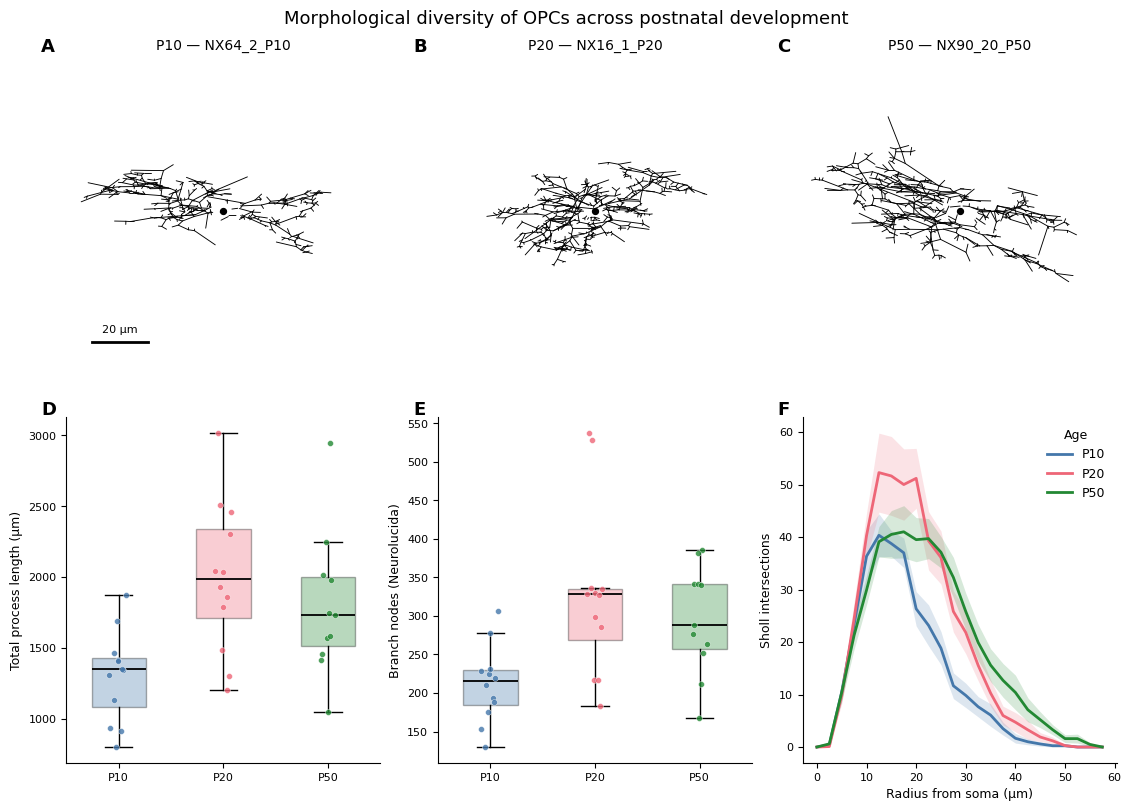

Saved: /mnt/data/fig1_run/figure1_outputs/Figure1_morphological_diversity.png
Saved: /mnt/data/fig1_run/figure1_outputs/Figure1_morphological_diversity.pdf


In [8]:
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig = plt.figure(figsize=(11.2, 7.8), constrained_layout=True)
gs = GridSpec(2, 6, figure=fig, height_ratios=[1.05, 1.0])

# A-C: representative reconstructions
recon_axes=[]
for i, (_, row) in enumerate(representatives.iterrows()):
    ax = fig.add_subplot(gs[0, 2*i:2*i+2])
    recon_axes.append(ax)
    cell_id = row["cell_id"]
    draw_reconstruction(ax, reconstructions[cell_id], f"{row['age']} — {cell_id}")

# Harmonise morphology panel limits and add one scale bar.
all_x=[]; all_y=[]
for row in representatives.to_dict("records"):
    recon = reconstructions[row["cell_id"]]
    soma=np.asarray(recon["soma_centroid"][:2], dtype=float)
    for seg in recon["segments"]:
        for key in ["start", "end"]:
            p=np.asarray(seg[key][:2], dtype=float)-soma
            all_x.append(p[0]); all_y.append(p[1])
lim=max(max(abs(np.asarray(all_x))), max(abs(np.asarray(all_y))))*1.06
for ax in recon_axes:
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
add_scale_bar(recon_axes[0], 20)

# D-E: robust morphology summaries
aD = fig.add_subplot(gs[1, 0:2])
distribution_plot(aD, "total_process_length_um", "Total process length (µm)")

aE = fig.add_subplot(gs[1, 2:4])
distribution_plot(aE, "n_nodes_neurolucida", "Branch nodes (Neurolucida)")

# F: Sholl curves
aF = fig.add_subplot(gs[1, 4:6])
for age in AGE_ORDER:
    s = sholl_summary.loc[sholl_summary.age == age]
    aF.plot(s["radius_um"], s["mean"], linewidth=2, label=age, color=AGE_COLORS[age])
    aF.fill_between(s["radius_um"], s["mean"]-s["sem"], s["mean"]+s["sem"],
                     color=AGE_COLORS[age], alpha=0.18, linewidth=0)
aF.set_xlabel("Radius from soma (µm)")
aF.set_ylabel("Sholl intersections")
aF.spines[["top", "right"]].set_visible(False)
aF.legend(frameon=False, title="Age")

for label, ax in zip(list("ABCDEF"), recon_axes + [aD, aE, aF]):
    ax.text(-0.08, 1.05, label, transform=ax.transAxes, fontweight="bold", fontsize=13, va="top")

fig.suptitle("Morphological diversity of OPCs across postnatal development", fontsize=13, y=1.02)

png_path = OUTPUT_DIR / "Figure1_morphological_diversity.png"
pdf_path = OUTPUT_DIR / "Figure1_morphological_diversity.pdf"
fig.savefig(png_path, dpi=400, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
print("Saved:", png_path)
print("Saved:", pdf_path)

## 8. Interpretation guardrails

This notebook deliberately separates **description** from **biological interpretation**:

- It identifies developmental differences in morphology but does not assume that age causes them.
- The 35 cells are the GM3-accepted modelling cohort; conclusions apply to that analysed cohort.
- Representative cells are chosen by a prespecified multivariate median-distance rule, not by visual preference.
- Kruskal–Wallis and Holm-adjusted Mann–Whitney tests are exploratory unless the manuscript analysis plan designates them as confirmatory.
- Sholl curves are shown as mean ± SEM; individual-cell source data are exported for alternative summaries or hierarchical modelling.

The final panel selection should be agreed with the experimental collaborators after inspecting effect sizes, data completeness, and the biological priorities of the manuscript.